<div style='text-align: center; padding: 30px'>
  <h1><strong>Plotting the Efficient Frontier</strong></h1>
  <h3><strong>Heriberto Espino Montelongo</strong></h1>
</div>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, expected_returns, plotting

In [18]:
file = r'cryptos-index.csv'
data_index = pd.read_csv(file, index_col="Date", parse_dates=True)

In [19]:
file = r'cryptos.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

In [20]:
mu = expected_returns.mean_historical_return(data, frequency=31)
s = risk_models.sample_cov(data, frequency=31)

# **MAX SHARPE BUY ONLY**

In [21]:
efbuy = EfficientFrontier(mu, s)    # Efficient Frontier Buy

In [22]:
efbuycopy = efbuy.deepcopy()

In [23]:
efbuyms = efbuy.max_sharpe()        # Efficient Frontier Buy Max Sharpe

In [24]:
wefbuy = efbuy.clean_weights()      # Weights Efficient Frontier Buy

# **MAX SHARPE CFDs**

In [25]:
efcfd = EfficientFrontier(mu, s, weight_bounds=(-1, 1))    # Efficient Frontier Buy

In [26]:
efcfdcopy = efcfd.deepcopy()        # a copy for not calculating again

In [27]:
efcfdms = efcfd.max_sharpe()        # Efficient Frontier Buy Max Sharpe

In [28]:
wefcfd = efcfd.clean_weights()      # Weights Efficient Frontier Buy

# **EFFICIENT FRONTIER PLOT**

In [29]:
efcfd = efcfdcopy.deepcopy()
efbuy = efbuycopy.deepcopy()

In [30]:
ewr = data_index['EWP'].pct_change().dropna()   # Equal Weighted Portfolio Returns
ppr = data_index['PP' ].pct_change().dropna()   # Ponderated Portfolio Returns

In [31]:
ewrm = ewr.mean()  # Equal Weighted Portfolio Mean
pprm = ppr.mean()  # Ponderated Portfolio Mean

ewrs = ewr.std()   # Equal Weighted Portfolio Standard Deviation
pprs = ppr.std()   # Ponderated Portfolio Standard Deviation


# make them mensual
ewrm = (1 + ewrm) ** ( 30/len(ewr) ) - 1
pprm = (1 + pprm) ** ( 30/len(ppr) ) - 1

ewrs = ewrs * np.sqrt(30)
pprs = pprs * np.sqrt(30)


SolverError: Solver 'OSQP' failed. Try another solver, or solve with verbose=True for more information.

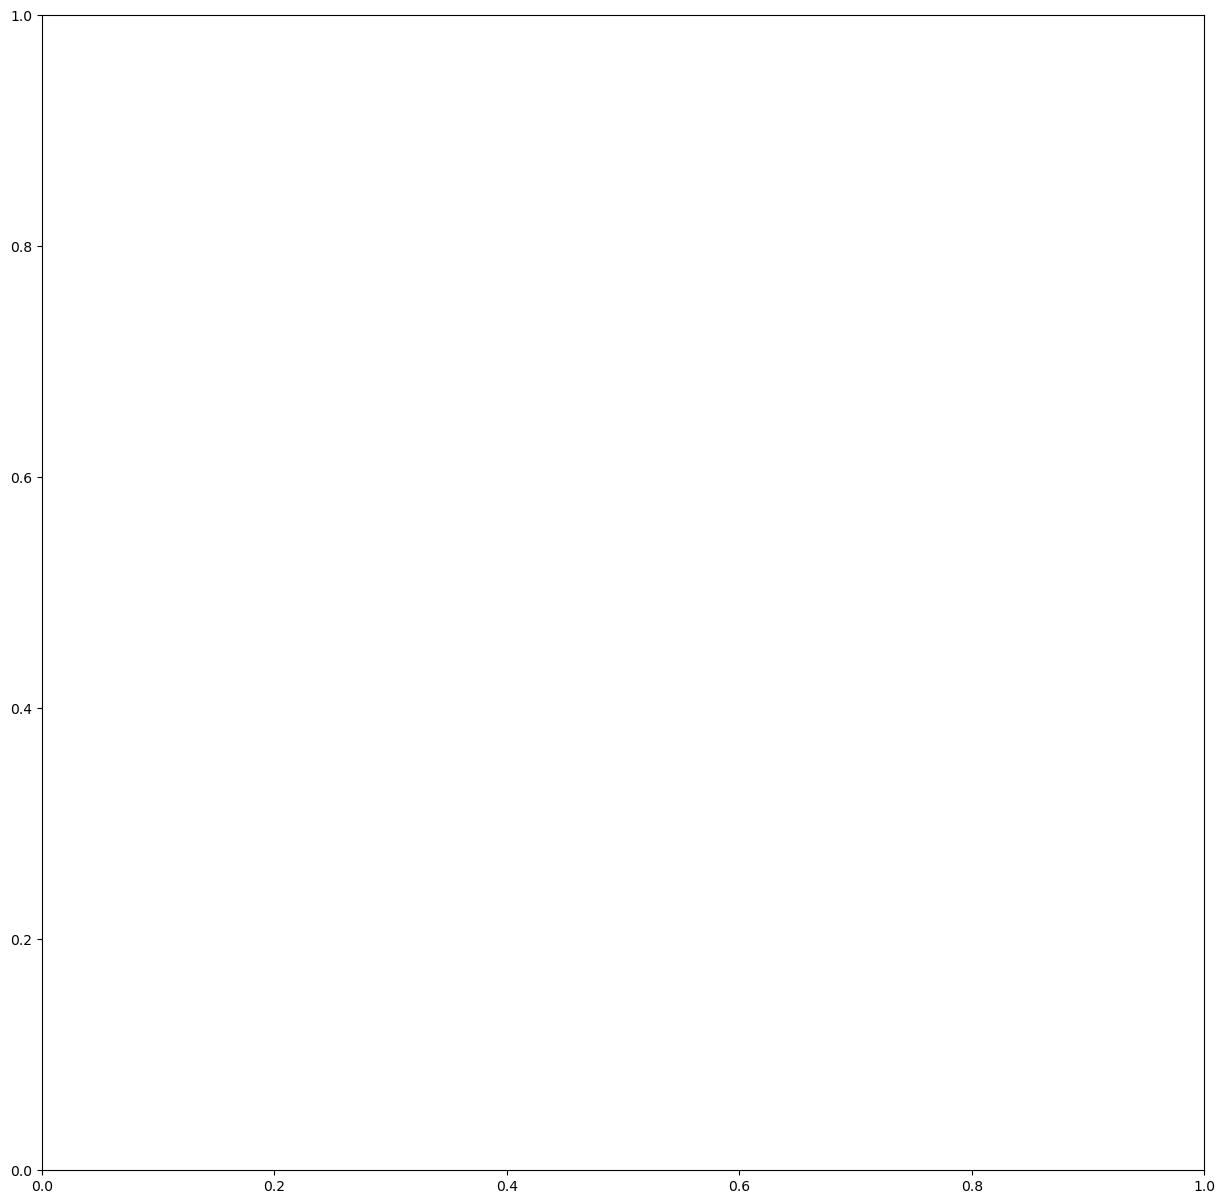

In [32]:
# # Set the color palette
# palette = sns.color_palette("tab10", len(data_index.columns))



# ------------------- Efficient Frontier for CFDs -------------------

# Plot the efficient frontier
fig, ax = plt.subplots(figsize=(15, 15))                                # Create a figure and a set of subplots
efcfdms = efcfd.deepcopy()                                              # Efficietn Frontier CFD Max Sharpe
efcfdpl = efcfd.deepcopy()                                              # Efficient Frontier CFD Plot
plotting.plot_efficient_frontier(efcfdpl, ax=ax, show_assets=False)     # Plot the efficient frontier (without the individual assets for now)


# Change the line of the efficient frontier
for line in ax.get_lines():
    if line.get_label() == 'Efficient frontier':
        line.set_color('#b1400d')
        line.set_linewidth(2)
        line.set_label("Frontera Eficiente para CFDs")


# find the tangency portfolio and plot it
efcfdms.max_sharpe()
ret_tangent, std_tangent, _ = efcfdms.portfolio_performance()
ax.scatter(std_tangent, ret_tangent, marker="*", s=120, c="#b1400d", label="Mejor Portafolio para CFDs")



# ------------------- Efficient Frontier for Only Buy -------------------



# Plot the efficient frontier
efbuyms = efbuy.deepcopy()                                              # Efficient Frontier Buy Max Sharpe
eybuypl = efbuy.deepcopy()                                              # Efficient Frontier Buy Plot
plotting.plot_efficient_frontier(eybuypl, ax=ax, show_assets=False)     # Plot the efficient frontier (without the individual assets for now) 


# Change the line of the efficient frontier
for line in ax.get_lines():
    if line.get_label() == 'Efficient frontier':
        line.set_color('#001c7f')
        line.set_linewidth(2)
        line.set_label("Frontera Eficiente para Compra")

# find the tangency portfolio and plot it
efbuyms.max_sharpe()
ret_tangent, std_tangent, _ = efbuyms.portfolio_performance()
ax.scatter(std_tangent, ret_tangent, marker="*", s=120, c="#001c7f", label="Mejor Portafolio para Compra")



# ------------------- Individual Assets -------------------


classification = {
    'BTC': 'Mayor Cap. Mercado',
    'ETH': 'Mayor Cap. Mercado',
    'USDT': 'Stablecoins',
    'BNB': 'Mayor Cap. Mercado',
    'USDC': 'Stablecoins',
    'XRP': 'Mayor Cap. Mercado',
    'ADA': 'Mayor Cap. Mercado',
    'SOL': 'Mayor Cap. Mercado',
    'DOGE': 'Memecoins',
    'DAI': 'Stablecoins',
    'TRX': 'Tokens Blockchain',
    'TON': 'Tokens Blockchain',
    'MATIC': 'Tokens Blockchain',
    'DOT': 'Tokens Blockchain',
    'AVAX': 'Tokens Blockchain',
    'STETH': 'Tokens Blockchain',
    'WSTETH': 'Activos Envueltos',
    'SUI': 'Tokens Blockchain',
    'WBTC': 'Activos Envueltos',
    'WTRX': 'Activos Envueltos',
    'LTC': 'Pagos & DeFi',
    'LINK': 'Pagos & DeFi',
    'XLM': 'Pagos & DeFi',
    'HBAR': 'Pagos & DeFi',
    'BCH': 'Pagos & DeFi',
    'SHIB': 'Memecoins',
    'LEO': 'Tokens de Exchange'
}

# Annotate each asset with its volatility (x) and expected return (y)
asset_volatilities = np.sqrt(np.diag(s))
asset_returns = np.array(mu)

# Define unique categories and create a color palette based on classification
palette = {
    'Activos Envueltos': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
    'Mayor Cap. Mercado': (1.0, 0.4980392156862745, 0.054901960784313725),
    'Memecoins': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
    'Pagos & DeFi': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
    'Stablecoins': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
    'Tokens Blockchain': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
    'Tokens de Exchange': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)
}

# Annotate each asset with its volatility (x) and expected return (y)
for i, txt in enumerate(data.columns):
    category = classification.get(txt, "Unknown")
    color = palette[category]
    ax.annotate(txt, (asset_volatilities[i], asset_returns[i]), xytext=(1, 1), textcoords='offset points', fontsize=6)
    ax.scatter(asset_volatilities[i], asset_returns[i], marker='o', color=color, s=20)

# Add the equal weighted portfolio to the plot
ax.scatter(pprs, pprm, marker="o", s=20, color='#12711c')

# Add text for the equal weighted portfolio
ax.annotate('PP', (pprs, pprm), xytext=(1, 1), textcoords='offset points', fontsize=6)


# ------------------- Inset with zoomed region -------------------

# Create inset of the zoomed region

x_zoom = (0, .4)
y_zoom = (-0.06, 0.04)

width = 0.3*1.5
height = 0.45*1.5

axins = ax.inset_axes([.95 - width, .95 - height, width, height]) # x, y, width, height
axins.set_xlim(x_zoom)
axins.set_ylim(y_zoom)

# Define unique categories and create a color palette based on classification


# Annotate each asset with its volatility (x) and expected return (y)
for i, txt in enumerate(data.columns):
    category = classification.get(txt, "Unknown")
    color = palette[category]
    axins.annotate(txt, (asset_volatilities[i], asset_returns[i]), xytext=(1, 1), textcoords='offset points', fontsize=9)
    axins.scatter(asset_volatilities[i], asset_returns[i], marker='o', color=color, s=20)

# Add the equal weighted portfolio to the plot
axins.scatter(pprs, pprm, marker="o", s=20, color='#12711c')

# Add text for the equal weighted portfolio
axins.annotate('PP', (pprs, pprm), xytext=(1, 1), textcoords='offset points', fontsize=9)


# plot the efficient frontier
efcfdpl2 = efcfd.deepcopy()

plotting.plot_efficient_frontier(efcfdpl2, ax=axins, show_assets=False, showfig=False)

for line in axins.get_lines():
    if line.get_label() == 'Efficient frontier':
        line.set_color('#8c0800')
        line.set_linewidth(2)
        line.set_label("Frontera Eficiente para CFDs")

axins.scatter(std_tangent, ret_tangent, marker="*", s=120, c="#8c0800")


efbuypl2 = efbuy.deepcopy()
plotting.plot_efficient_frontier(efbuypl2, ax=axins, show_assets=False, showfig=False)
for line in axins.get_lines():
    if line.get_label() == 'Efficient frontier':
        line.set_color('#001c7f')
        line.set_linewidth(2)
        line.set_label("Frontera Eficiente para CFDs")
axins.scatter(std_tangent, ret_tangent, marker="*", s=180, c="#001c7f")

# add grid
axins.grid(True, color='gray', linestyle='--', linewidth=0.5)
axins.get_legend().remove()

# Mark the zoomed area on the main plot
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")



# ------------------- Final adjustments -------------------

# Add new legend with updated labels
handles, labels = ax.get_legend_handles_labels()
new_labels = ['Cryptos' if label == 'assets' else label for label in labels]
ax.legend(handles, new_labels)
ax.set_facecolor('white')

ax.grid(True, color='gray', linestyle='--', linewidth=0.5)
# ax.set_xticks(np.arange(0, int(ax.get_xlim()[1]) + 1, 1))


# Plot the efficient frontier
plt.tight_layout()
plt.title('Frontera Eficiente Compuesta Mensualmente', fontsize=35, color='black', weight="bold")
ax.set_xlabel('Volatilidad Anual')
ax.set_ylabel('Retorno Mensual')
plt.savefig("svg/04-efficient_frontier-1m.pdf", format="pdf", bbox_inches='tight')

plt.show()

In [ ]:
# view seaborn color palett dark   
sns.color_palette('dark')

[(0.0, 0.10980392156862745, 0.4980392156862745),
 (0.6941176470588235, 0.25098039215686274, 0.050980392156862744),
 (0.07058823529411765, 0.44313725490196076, 0.10980392156862745),
 (0.5490196078431373, 0.03137254901960784, 0.0),
 (0.34901960784313724, 0.11764705882352941, 0.44313725490196076),
 (0.34901960784313724, 0.1843137254901961, 0.050980392156862744),
 (0.6352941176470588, 0.20784313725490197, 0.5098039215686274),
 (0.23529411764705882, 0.23529411764705882, 0.23529411764705882),
 (0.7215686274509804, 0.5215686274509804, 0.0392156862745098),
 (0.0, 0.38823529411764707, 0.4549019607843137)]

In [ ]:
sns.color_palette('dark')[0]

(0.0, 0.10980392156862745, 0.4980392156862745)

In [ ]:
sns.color_palette('dark')[3]

(0.5490196078431373, 0.03137254901960784, 0.0)